# Phishing Attack Detection using Machine Learning  
## Adapted Reproduction and Critical Evaluation Notebook

**Course:** Data Science in Cyber  
**Selected source:** RimTouny / Phishing-Attack-Detection-using-Machine-Learning  
**Adapted dataset:** `dataset_phishing.csv`

This notebook is an adapted and documented version of the selected GitHub phishing detection project.  
The original notebook could not be executed directly because the processed CSV used by the author was loaded from a local Windows path.  
With lecturer approval, this notebook runs the phishing detection workflow on `dataset_phishing.csv`.

The main task is binary classification:

- `legitimate` → benign URL → label `0`
- `phishing` → malicious phishing URL → label `1`

## Notebook Structure

This notebook follows the final project requirements:

1. Data Loading  
2. Data Inspection  
3. Temporal Analysis  
4. Exploratory Data Analysis (EDA)  
5. Feature Engineering and Preprocessing  
6. Model Training  
7. Evaluation  
8. Error Analysis  
9. Saving Results  
10. Final Notebook Conclusions

# 1. Imports and Global Settings

In [1]:
from pathlib import Path
import warnings
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    VotingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    matthews_corrcoef,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 120)

# 2. Data Loading

The dataset must be named:

`dataset_phishing.csv`

Recommended repository path:

`data/dataset_phishing.csv`

For Google Colab, the helper function below also checks common upload locations.

In [2]:
def find_dataset_path(filename: str = "dataset_phishing.csv") -> Path:
    """Find the dataset in common local, GitHub, and Colab locations."""
    candidate_paths = [
        Path("data") / filename,
        Path("/content/data") / filename,
        Path("/content") / filename,
        Path("/") / filename,
        Path(filename),
        Path("../data") / filename
    ]

    for path in candidate_paths:
        if path.exists():
            return path

    raise FileNotFoundError(
        f"Could not find {filename}. "
        "Please upload it to data/dataset_phishing.csv or to the Colab file panel."
    )


dataset_path = find_dataset_path()
Dataset = pd.read_csv(dataset_path)

print("Loaded dataset from:", dataset_path)
print("Dataset shape:", Dataset.shape)
display(Dataset.head())

Loaded dataset from: /dataset_phishing.csv
Dataset shape: (11430, 89)


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,nb_underscore,nb_tilde,nb_percent,nb_slash,nb_star,nb_colon,nb_comma,nb_semicolumn,nb_dollar,nb_space,nb_www,nb_com,nb_dslash,http_in_path,https_token,ratio_digits_url,ratio_digits_host,punycode,port,tld_in_path,tld_in_subdomain,abnormal_subdomain,nb_subdomains,prefix_suffix,random_domain,shortening_service,path_extension,nb_redirection,nb_external_redirection,length_words_raw,char_repeat,shortest_words_raw,shortest_word_host,shortest_word_path,longest_words_raw,longest_word_host,longest_word_path,avg_words_raw,avg_word_host,avg_word_path,phish_hints,domain_in_brand,brand_in_subdomain,brand_in_path,suspecious_tld,statistical_report,nb_hyperlinks,ratio_intHyperlinks,ratio_extHyperlinks,ratio_nullHyperlinks,nb_extCSS,ratio_intRedirection,ratio_extRedirection,ratio_intErrors,ratio_extErrors,login_form,external_favicon,links_in_tags,submit_email,ratio_intMedia,ratio_extMedia,sfh,iframe,popup_window,safe_anchor,onmouseover,right_clic,empty_title,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,0,0,0,0,3,0,1,0,0,0,0,1,0,0,0,1,0.000000,0.0,0,0,0,0,0,3,0,0,0,0,0,0,4,4,3,3,3,11,11,6,5.750000,7.0,4.500000,0,0,0,0,0,0,17,0.529412,0.470588,0,0,0,0.875000,0,0.500000,0,0,80.000000,0,100.000000,0.000000,0,0,0,0.0,0,0,0,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,0,0,0,0,5,0,1,0,0,0,0,0,0,0,0,1,0.220779,0.0,0,0,0,0,0,1,0,0,0,0,1,0,4,4,2,19,2,32,19,32,15.750000,19.0,14.666667,0,0,0,0,0,0,30,0.966667,0.033333,0,0,0,0.000000,0,0.000000,0,0,100.000000,0,80.000000,20.000000,0,0,0,100.0,0,0,0,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,3,2,0,0,5,0,1,0,0,0,0,0,1,0,0,0,0.150794,0.0,0,0,0,1,0,3,1,0,0,0,1,0,12,2,2,3,2,17,13,17,8.250000,8.4,8.142857,0,0,0,0,0,0,4,1.000000,0.000000,0,0,0,0.000000,0,0.000000,0,0,100.000000,0,0.000000,0.000000,0,0,0,100.0,0,0,0,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,0,0,0,0,2,0,1,0,0,0,0,0,0,0,0,1,0.000000,0.0,0,0,0,0,0,2,0,0,0,0,1,0,1,0,5,5,0,5,5,0,5.000000,5.0,0.000000,0,0,0,0,0,0,149,0.973154,0.026846,0,0,0,0.250000,0,0.250000,0,0,100.000000,0,96.428571,3.571429,0,0,0,62.5,0,0,0,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,0,0,0,0,5,0,1,0,0,0,0,1,0,0,0,1,0.000000,0.0,0,0,0,0,0,2,0,0,0,0,1,0,6,3,3,3,4,11,7,11,6.333333,5.0,7.000000,0,0,0,0,0,0,102,0.470588,0.529412,0,0,0,0.537037,0,0.018519,1,0,76.470588,0,0.000000,100.000000,0,0,0,0.0,0,0,0,0,1,0,224,8175,8725,0,0,6,legitimate


# 3. Data Inspection

This section checks the basic structure and quality of the dataset:

- dataset size  
- feature types  
- index and column names  
- missing values  
- duplicate rows  
- single-value columns  
- duplicated features

In [3]:
print("Number of rows:", Dataset.shape[0])
print("Number of columns:", Dataset.shape[1])

print("\nFirst 10 column names:")
print(Dataset.columns[:10].tolist())

print("\nLast 10 column names:")
print(Dataset.columns[-10:].tolist())

print("\nData types:")
display(Dataset.dtypes.value_counts())

print("\nDetailed info:")
Dataset.info()

Number of rows: 11430
Number of columns: 89

First 10 column names:
['url', 'length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens', 'nb_at', 'nb_qm', 'nb_and', 'nb_or']

Last 10 column names:
['domain_in_title', 'domain_with_copyright', 'whois_registered_domain', 'domain_registration_length', 'domain_age', 'web_traffic', 'dns_record', 'google_index', 'page_rank', 'status']

Data types:


,count
int64,74
float64,13
object,2



Detailed info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11430 entries, 0 to 11429
Data columns (total 89 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   url                         11430 non-null  object 
 1   length_url                  11430 non-null  int64  
 2   length_hostname             11430 non-null  int64  
 3   ip                          11430 non-null  int64  
 4   nb_dots                     11430 non-null  int64  
 5   nb_hyphens                  11430 non-null  int64  
 6   nb_at                       11430 non-null  int64  
 7   nb_qm                       11430 non-null  int64  
 8   nb_and                      11430 non-null  int64  
 9   nb_or                       11430 non-null  int64  
 10  nb_eq                       11430 non-null  int64  
 11  nb_underscore               11430 non-null  int64  
 12  nb_tilde                    11430 non-null  int64  
 13  nb_percent     

## 3.1 Index and Column Names Analysis

Each row represents one URL sample.  
A default numeric index is acceptable because there is no natural unique identifier such as an event ID or timestamp.

In [4]:
print("Index name:", Dataset.index.name)
print("Index type:", type(Dataset.index))
print("Is index unique?", Dataset.index.is_unique)
print("Is index monotonic increasing?", Dataset.index.is_monotonic_increasing)

print("\nAre all column names unique?", Dataset.columns.is_unique)

if not Dataset.columns.is_unique:
    duplicated_column_names = Dataset.columns[Dataset.columns.duplicated()].tolist()
    print("Duplicated column names:", duplicated_column_names)
else:
    print("No duplicated column names were found.")

print("\nColumn names:")
print(Dataset.columns.tolist())

Index name: None
Index type: <class 'pandas.core.indexes.range.RangeIndex'>
Is index unique? True
Is index monotonic increasing? True

Are all column names unique? True
No duplicated column names were found.

Column names:
['url', 'length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens', 'nb_at', 'nb_qm', 'nb_and', 'nb_or', 'nb_eq', 'nb_underscore', 'nb_tilde', 'nb_percent', 'nb_slash', 'nb_star', 'nb_colon', 'nb_comma', 'nb_semicolumn', 'nb_dollar', 'nb_space', 'nb_www', 'nb_com', 'nb_dslash', 'http_in_path', 'https_token', 'ratio_digits_url', 'ratio_digits_host', 'punycode', 'port', 'tld_in_path', 'tld_in_subdomain', 'abnormal_subdomain', 'nb_subdomains', 'prefix_suffix', 'random_domain', 'shortening_service', 'path_extension', 'nb_redirection', 'nb_external_redirection', 'length_words_raw', 'char_repeat', 'shortest_words_raw', 'shortest_word_host', 'shortest_word_path', 'longest_words_raw', 'longest_word_host', 'longest_word_path', 'avg_words_raw', 'avg_word_host', 'avg_word_p

## 3.2 Missing Value Analysis

In [5]:
missing_values = Dataset.isna().sum().sort_values(ascending=False)
missing_percent = (missing_values / len(Dataset) * 100).round(2)

missing_table = pd.DataFrame({
    "missing_count": missing_values,
    "missing_percent": missing_percent
})

display(missing_table[missing_table["missing_count"] > 0])

if missing_values.sum() == 0:
    print("No missing values were found in the dataset.")
else:
    print("Total missing values:", int(missing_values.sum()))

,missing_count,missing_percent


No missing values were found in the dataset.


## 3.3 Duplicate Rows

In [6]:
duplicate_rows = Dataset.duplicated().sum()
print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 0


## 3.4 Single-Value Columns

Columns with only one unique value do not help classification because they cannot distinguish between phishing and legitimate URLs.

In [7]:
unique_counts = Dataset.nunique(dropna=False).sort_values()
single_value_columns = unique_counts[unique_counts <= 1]

print("Single-value columns:")
display(single_value_columns)

Single-value columns:


,0
nb_or,1
ratio_intRedirection,1
ratio_nullHyperlinks,1
ratio_intErrors,1
submit_email,1
sfh,1


## 3.5 Duplicated Features

Duplicated features create redundancy and can reduce interpretability.  
To detect duplicated feature values efficiently, we hash the values of every column and compare columns with identical hashes.

In [8]:
def find_duplicate_columns(data: pd.DataFrame) -> list:
    """Return pairs of columns that contain exactly the same values."""
    hashes = {}
    duplicates = []

    for column in data.columns:
        column_hash = pd.util.hash_pandas_object(data[column], index=False).sum()

        if column_hash in hashes:
            for previous_column in hashes[column_hash]:
                if data[column].equals(data[previous_column]):
                    duplicates.append((previous_column, column))
            hashes[column_hash].append(column)
        else:
            hashes[column_hash] = [column]

    return duplicates


duplicate_feature_pairs = find_duplicate_columns(Dataset.drop(columns=["url", "status"], errors="ignore"))

print("Number of duplicated feature pairs:", len(duplicate_feature_pairs))
print("Duplicated feature pairs:")
display(duplicate_feature_pairs)

Number of duplicated feature pairs: 15
Duplicated feature pairs:


[('nb_or', 'ratio_nullHyperlinks'),
 ('nb_or', 'ratio_intRedirection'),
 ('ratio_nullHyperlinks', 'ratio_intRedirection'),
 ('nb_or', 'ratio_intErrors'),
 ('ratio_nullHyperlinks', 'ratio_intErrors'),
 ('ratio_intRedirection', 'ratio_intErrors'),
 ('nb_or', 'submit_email'),
 ('ratio_nullHyperlinks', 'submit_email'),
 ('ratio_intRedirection', 'submit_email'),
 ('ratio_intErrors', 'submit_email'),
 ('nb_or', 'sfh'),
 ('ratio_nullHyperlinks', 'sfh'),
 ('ratio_intRedirection', 'sfh'),
 ('ratio_intErrors', 'sfh'),
 ('submit_email', 'sfh')]

# 4. Target Variable Preparation

The original dataset uses the target column `status`.

We encode it as a numeric label:

- `legitimate` → `0`
- `phishing` → `1`

This is label encoding of the target variable, not one-hot encoding, because the task is binary classification.

In [9]:
print("Target values before encoding:")
display(Dataset["status"].value_counts())

Dataset["label"] = Dataset["status"].map({
    "legitimate": 0,
    "phishing": 1
})

if Dataset["label"].isna().any():
    raise ValueError("Some values in the status column could not be mapped to numeric labels.")

print("\nTarget values after encoding:")
display(Dataset[["status", "label"]].head())

display(pd.DataFrame({
    "count": Dataset["label"].value_counts().sort_index(),
    "meaning": ["legitimate", "phishing"]
}))

Target values before encoding:


,count
status,
legitimate,5715
phishing,5715



Target values after encoding:


,status,label
0,legitimate,0
1,phishing,1
2,phishing,1
3,legitimate,0
4,legitimate,0


,count,meaning
label,,
0,5715,legitimate
1,5715,phishing


# 5. Temporal Analysis

The assignment asks for temporal analysis when temporal features are available.

This dataset contains URL and webpage features, but it does not appear to contain explicit time/date columns.  
This is a limitation because phishing behavior can change over time, and without timestamps we cannot directly analyze temporal drift.

In [10]:
possible_temporal_columns = [
    column for column in Dataset.columns
    if any(token in column.lower() for token in ["date", "time", "timestamp", "created", "updated"])
]

print("Possible temporal columns:", possible_temporal_columns)

if len(possible_temporal_columns) == 0:
    print("No explicit temporal columns were found. Temporal drift cannot be evaluated directly.")
else:
    for column in possible_temporal_columns:
        parsed = pd.to_datetime(Dataset[column], errors="coerce")
        print(column, "valid datetime ratio:", parsed.notna().mean())

Possible temporal columns: []
No explicit temporal columns were found. Temporal drift cannot be evaluated directly.


# 6. Exploratory Data Analysis (EDA)

EDA helps us understand the dataset before training models.  
In cybersecurity, this is important because a model can perform well numerically but still fail to support practical defense decisions.

## 6.1 Class Imbalance / Prevalence Analysis

This checks whether the dataset has many more examples of one class than the other.  
In phishing detection, class imbalance matters because accuracy can be misleading if one class dominates the dataset.

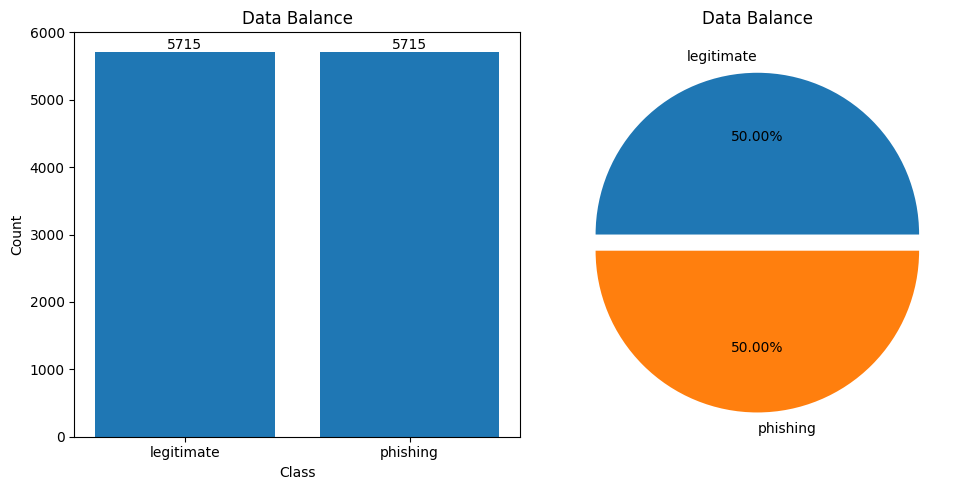

,count,percent
status,,
legitimate,5715,50.0
phishing,5715,50.0


In [11]:
class_counts = Dataset["status"].value_counts()
class_percent = (class_counts / class_counts.sum() * 100).round(2)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

bars = axes[0].bar(class_counts.index.astype(str), class_counts.values)
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].set_title("Data Balance")

for bar, count in zip(bars, class_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(count),
        ha="center",
        va="bottom"
    )

class_counts.plot.pie(
    explode=[0, 0.1],
    autopct="%1.2f%%",
    ax=axes[1]
)
axes[1].set_ylabel("")
axes[1].set_title("Data Balance")

plt.tight_layout()
plt.show()

balance_table = pd.DataFrame({
    "count": class_counts,
    "percent": class_percent
})

display(balance_table)

**Interpretation:**  
The dataset is balanced if the two classes have approximately the same number of samples.  
This reduces the risk that accuracy will be misleading due to class imbalance.  
However, in real-world deployment, phishing URLs may be much rarer than legitimate URLs, so this balanced dataset may not perfectly represent real-world prevalence.

## 6.2 Feature Type Summary

In [12]:
numeric_columns = Dataset.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = Dataset.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:", len(numeric_columns))
print("Categorical / object columns:", len(categorical_columns))
print("Categorical / object columns:", categorical_columns)

Numeric columns: 88
Categorical / object columns: 2
Categorical / object columns: ['url', 'status']


## 6.3 Feature Distributions

We compare selected URL and webpage features between legitimate and phishing URLs.

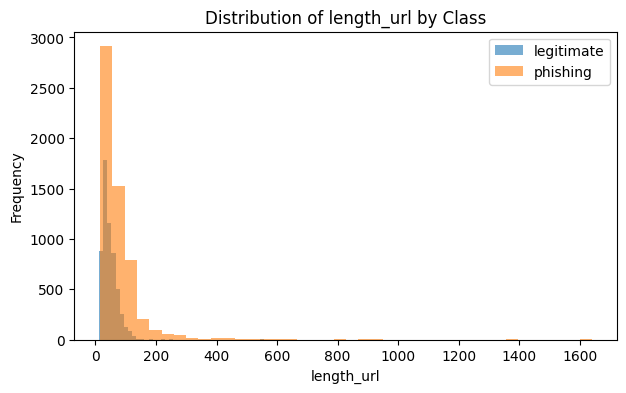

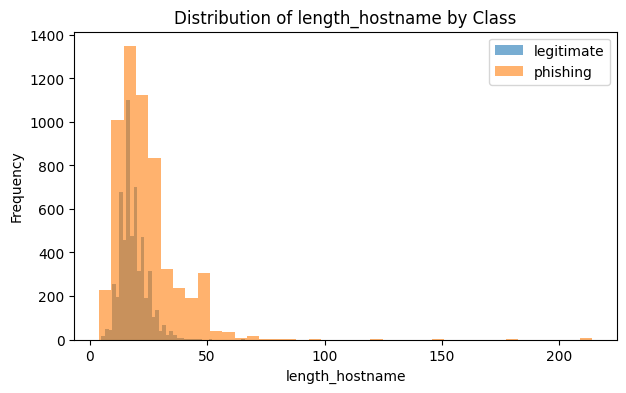

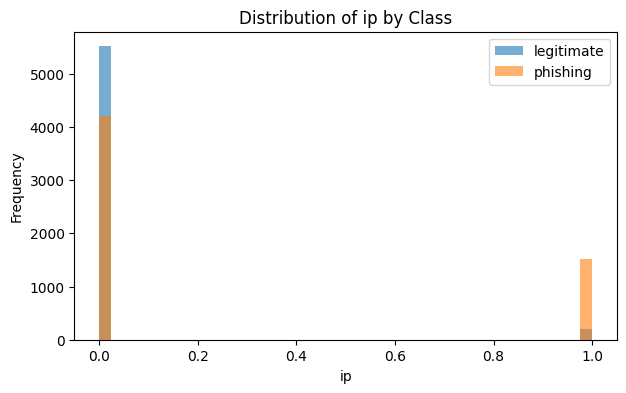

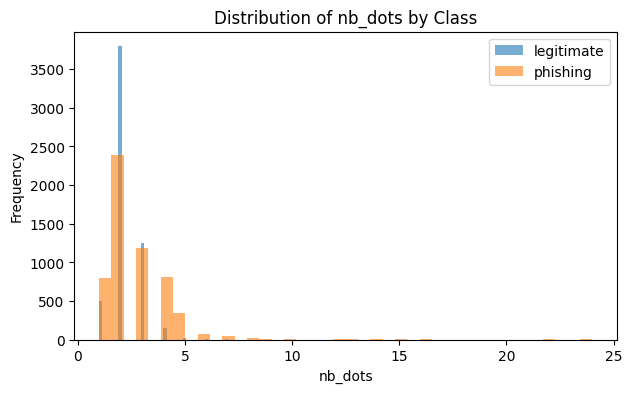

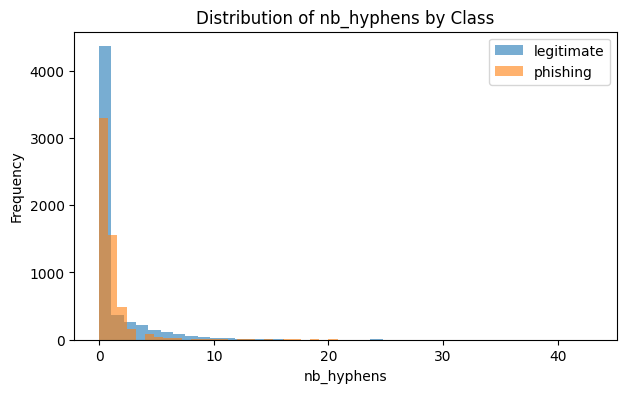

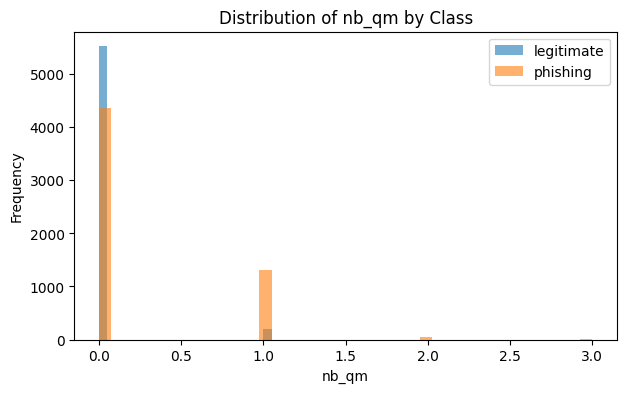

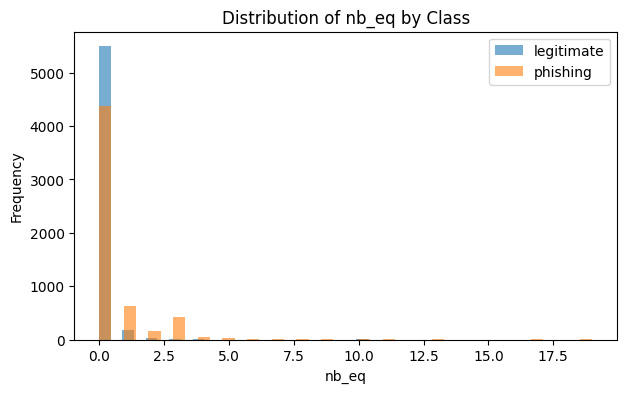

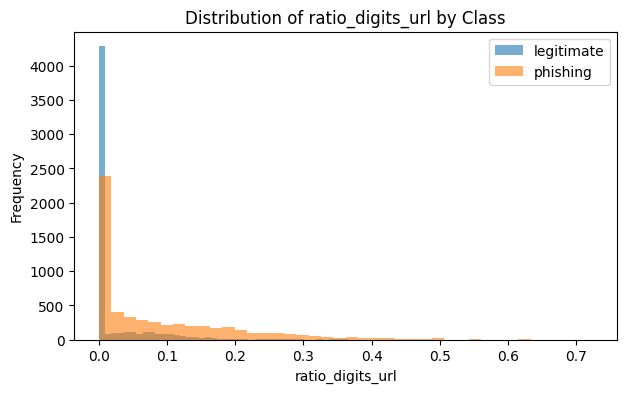

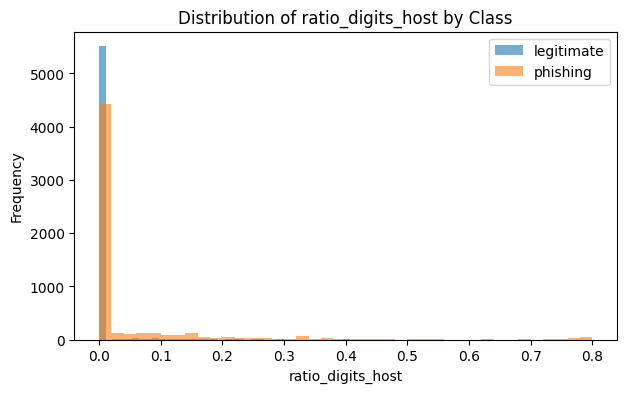

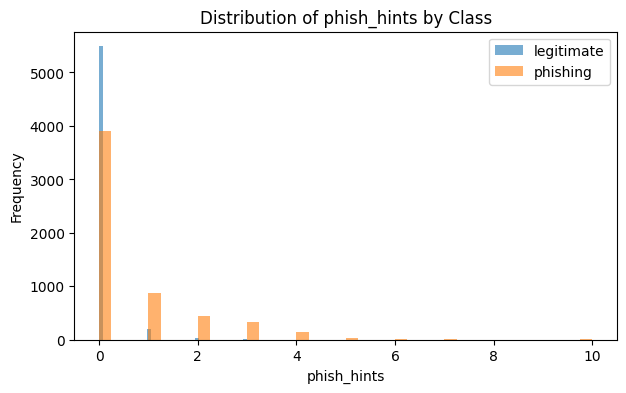

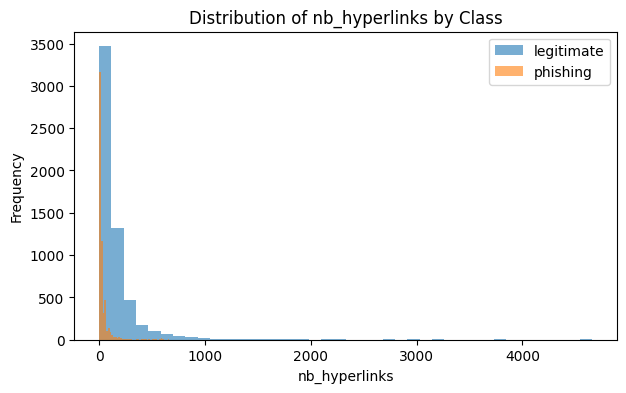

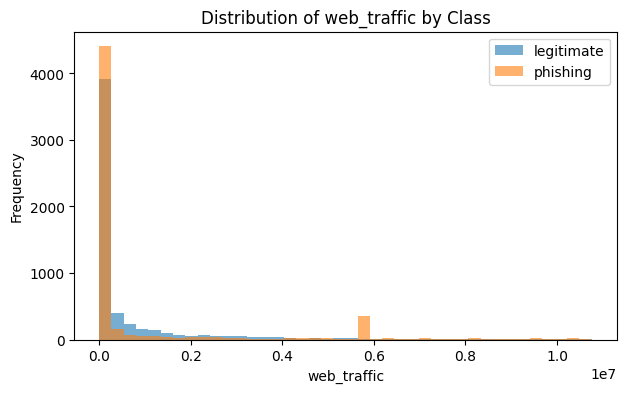

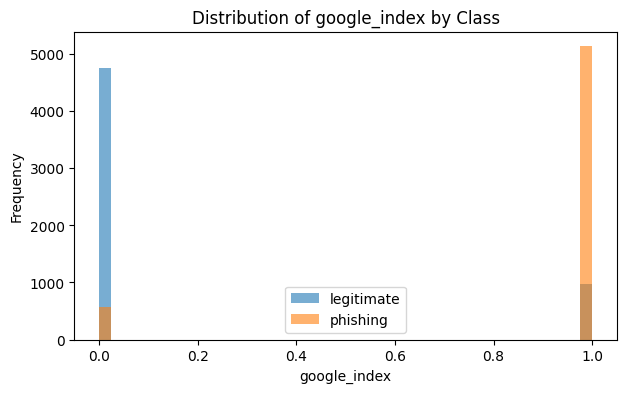

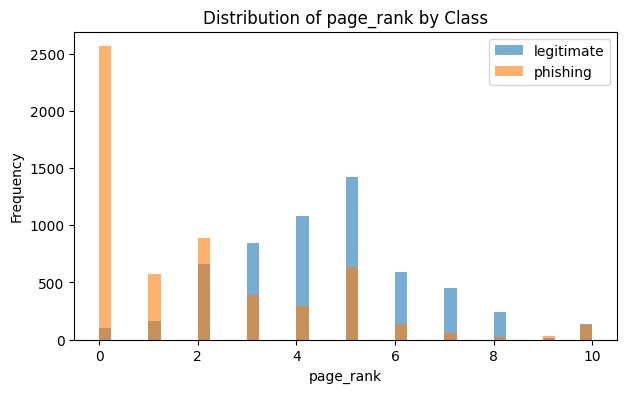

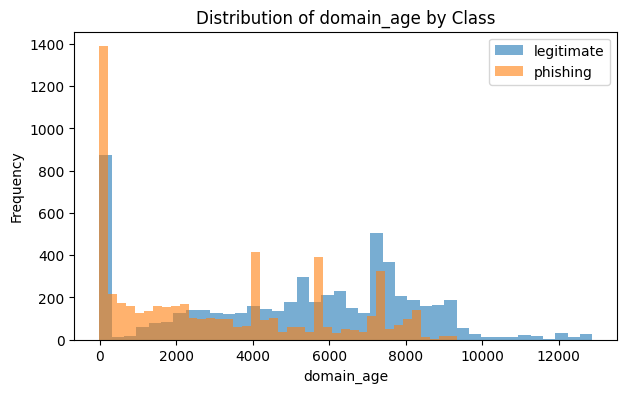

In [13]:
selected_features = [
    "length_url", "length_hostname", "ip", "nb_dots", "nb_hyphens",
    "nb_qm", "nb_eq", "ratio_digits_url", "ratio_digits_host",
    "phish_hints", "nb_hyperlinks", "web_traffic",
    "google_index", "page_rank", "domain_age"
]

selected_features = [feature for feature in selected_features if feature in Dataset.columns]

for feature in selected_features:
    plt.figure(figsize=(7, 4))
    plt.hist(
        Dataset.loc[Dataset["label"] == 0, feature].dropna(),
        bins=40,
        alpha=0.6,
        label="legitimate"
    )
    plt.hist(
        Dataset.loc[Dataset["label"] == 1, feature].dropna(),
        bins=40,
        alpha=0.6,
        label="phishing"
    )
    plt.title(f"Distribution of {feature} by Class")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

## 6.4 Group-By and Crosstab Analysis

This section checks whether selected binary or discrete features behave differently for phishing and legitimate URLs.

In [14]:
groupby_features = [feature for feature in ["length_url", "phish_hints", "nb_hyperlinks", "web_traffic", "page_rank"] if feature in Dataset.columns]

print("Mean values by class:")
display(Dataset.groupby("status")[groupby_features].mean().T)

if "google_index" in Dataset.columns:
    print("\nCrosstab: google_index vs status")
    display(pd.crosstab(Dataset["google_index"], Dataset["status"], normalize="index").round(3))

if "ip" in Dataset.columns:
    print("\nCrosstab: ip vs status")
    display(pd.crosstab(Dataset["ip"], Dataset["status"], normalize="index").round(3))

if "shortening_service" in Dataset.columns:
    print("\nCrosstab: shortening_service vs status")
    display(pd.crosstab(Dataset["shortening_service"], Dataset["status"], normalize="index").round(3))

Mean values by class:


status,legitimate,phishing
length_url,47.381452,74.871916
phish_hints,0.045144,0.610324
nb_hyperlinks,144.323360,30.056168
web_traffic,736251.807874,977261.478740
page_rank,4.482415,1.889064



Crosstab: google_index vs status


status,legitimate,phishing
google_index,,
0,0.891,0.109
1,0.158,0.842



Crosstab: ip vs status


status,legitimate,phishing
ip,,
0,0.568,0.432
1,0.118,0.882



Crosstab: shortening_service vs status


status,legitimate,phishing
shortening_service,,
0,0.520,0.480
1,0.359,0.641


## 6.5 Outlier Analysis

Cybersecurity datasets often contain skewed and heavy-tailed variables.  
For example, a small number of URLs may be extremely long or contain many hyperlinks.

We use the IQR method because it is more robust to outliers than mean and standard deviation.

In [15]:
def outlier_rate_iqr(series: pd.Series) -> float:
    """Compute the percentage of IQR-based outliers in a numeric series."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    if iqr == 0:
        return 0.0

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    return ((series < lower_bound) | (series > upper_bound)).mean()


feature_columns_for_outliers = [
    column for column in Dataset.select_dtypes(include=[np.number]).columns
    if column != "label"
]

outlier_rates = pd.Series({
    column: outlier_rate_iqr(Dataset[column])
    for column in feature_columns_for_outliers
}).sort_values(ascending=False)

outlier_table = (outlier_rates * 100).round(2).rename("outlier_percent").to_frame()
display(outlier_table.head(20))

,outlier_percent
ratio_extErrors,18.80
web_traffic,18.71
ratio_extMedia,17.60
domain_registration_length,13.38
shortest_words_raw,12.55
nb_hyphens,11.99
shortest_word_host,9.56
longest_words_raw,9.06
nb_extCSS,8.92
ratio_extRedirection,8.74


## 6.6 Correlation Analysis

We use **Spearman correlation** with the target because many URL-based features are binary, counts, skewed, or non-normally distributed.

- Pearson correlation measures linear relationships between continuous variables.
- Spearman correlation measures monotonic relationships using ranks and is more robust to outliers.
- Kendall correlation is useful for rank consistency, especially with smaller datasets.

For this project, Spearman is a suitable choice because URL and webpage features do not necessarily have linear relationships with the phishing label.

,spearman_correlation
google_index,0.731171
nb_hyperlinks,-0.551603
page_rank,-0.546889
nb_www,-0.448259
ratio_digits_url,0.379524
phish_hints,0.367846
domain_in_title,0.342807
web_traffic,-0.340268
ip,0.321698
domain_age,-0.310385


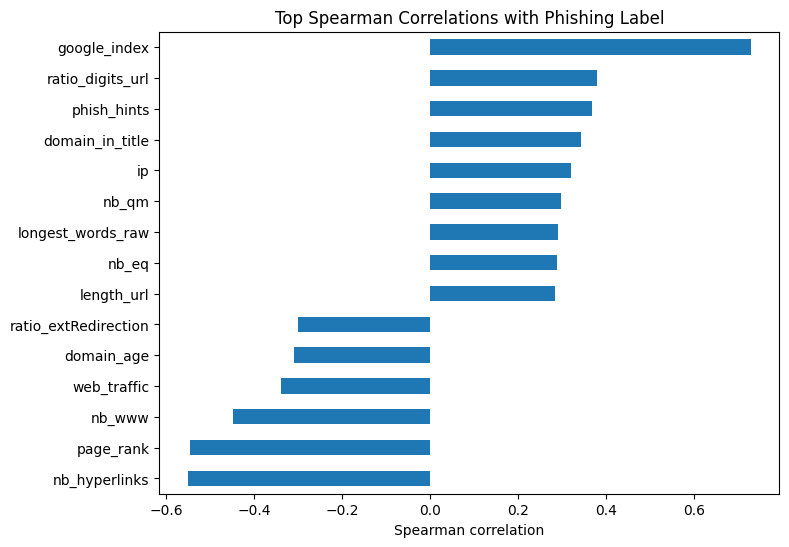

In [16]:
model_numeric_columns = [
    column for column in Dataset.select_dtypes(include=[np.number]).columns
    if column != "label"
]

spearman_correlation = (
    Dataset[model_numeric_columns + ["label"]]
    .corr(method="spearman")["label"]
    .drop("label")
)

top_spearman = spearman_correlation.reindex(
    spearman_correlation.abs().sort_values(ascending=False).index
)

display(top_spearman.head(20).rename("spearman_correlation").to_frame())

plt.figure(figsize=(8, 6))
top_spearman.head(15).sort_values().plot(kind="barh")
plt.title("Top Spearman Correlations with Phishing Label")
plt.xlabel("Spearman correlation")
plt.show()

# 7. Feature Engineering and Preprocessing

The dataset already contains many engineered URL and webpage features.  
Our preprocessing focuses on preparing the data correctly for machine learning.

Steps:

1. Encode the target variable.  
2. Remove irrelevant columns such as `url` and `status`.  
3. Remove constant features.  
4. Remove duplicated features if any exist.  
5. Fill numeric missing values if needed.  
6. Use feature scaling only inside pipelines for models that require it.

In [17]:
def prepare_feature_matrix(data: pd.DataFrame, target_column: str = "label"):
    """Prepare feature matrix X and target vector y."""
    y = data[target_column].astype(int)

    X = data.drop(columns=["url", "status", target_column], errors="ignore").copy()
    X = X.select_dtypes(include=[np.number])

    constant_columns = [column for column in X.columns if X[column].nunique(dropna=False) <= 1]
    X = X.drop(columns=constant_columns)

    duplicate_pairs = find_duplicate_columns(X)
    duplicated_columns_to_remove = sorted({second for _, second in duplicate_pairs})
    X = X.drop(columns=duplicated_columns_to_remove, errors="ignore")

    X = X.fillna(X.median(numeric_only=True))

    preprocessing_info = {
        "constant_columns": constant_columns,
        "duplicated_columns_removed": duplicated_columns_to_remove,
        "final_feature_count": X.shape[1]
    }

    return X, y, preprocessing_info


X, y, preprocessing_info = prepare_feature_matrix(Dataset)

print("Final feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nPreprocessing info:")
display(preprocessing_info)

Final feature matrix shape: (11430, 81)
Target shape: (11430,)

Preprocessing info:


{'constant_columns': ['nb_or',
  'ratio_nullHyperlinks',
  'ratio_intRedirection',
  'ratio_intErrors',
  'submit_email',
  'sfh'],
 'duplicated_columns_removed': [],
 'final_feature_count': 81}

## 7.1 Feature Scaling Decision

Feature scaling is applied inside pipelines for scale-sensitive models:

- Logistic Regression  
- K-Nearest Neighbors  

Tree-based models such as Decision Tree, Random Forest, Extra Trees, and Gradient Boosting do not require scaling because they split features using thresholds.

## 7.2 Dimensionality Reduction Decision

Dimensionality reduction was not applied because the number of features is manageable and interpretability is important.  
Keeping the original engineered features allows us to analyze which URL and webpage characteristics are related to phishing.

# 8. Train/Test Split

We use an 80/20 stratified split.  
Stratification preserves the phishing/legitimate ratio in both training and testing sets.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True).sort_index().rename({0: "legitimate", 1: "phishing"}))

print("\nTesting target distribution:")
display(y_test.value_counts(normalize=True).sort_index().rename({0: "legitimate", 1: "phishing"}))

X_train shape: (9144, 81)
X_test shape: (2286, 81)

Training target distribution:


,proportion
label,
legitimate,0.5
phishing,0.5



Testing target distribution:


,proportion
label,
legitimate,0.5
phishing,0.5


# 9. Model Training

The assignment requires at least two models.  
We train several models to compare simple, interpretable baselines with stronger non-linear ensemble methods.

Models:

1. Logistic Regression  
2. Decision Tree  
3. Random Forest  
4. Extra Trees  
5. Gradient Boosting  
6. K-Nearest Neighbors

In [19]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=120,
        max_depth=18,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=120,
        max_depth=18,
        min_samples_leaf=2,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=120,
        learning_rate=0.08,
        random_state=RANDOM_STATE
    ),

    "K-Nearest Neighbors": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", KNeighborsClassifier(n_neighbors=5))
    ])
}

# 10. Evaluation

We evaluate classification performance using:

- Accuracy  
- Precision  
- Recall  
- F1 Score  
- F2 Score  
- MCC  
- ROC-AUC  
- Confusion Matrix  

In phishing detection, **False Negatives** are especially dangerous because a phishing URL is classified as legitimate.

In [20]:
def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    """Train and evaluate one classification model."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    y_score = None
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    return {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "f2": fbeta_score(y_test, y_pred, beta=2, zero_division=0),
        "mcc": matthews_corrcoef(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_score) if y_score is not None else np.nan,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }


results = []
trained_models = {}

for model_name, model in models.items():
    result = evaluate_model(model_name, model, X_train, X_test, y_train, y_test)
    results.append(result)
    trained_models[model_name] = model

results_df = pd.DataFrame(results).sort_values("f1", ascending=False)
display(results_df)

,model,accuracy,precision,recall,f1,f2,mcc,roc_auc,tn,fp,fn,tp
2,Random Forest,0.962380,0.957576,0.967629,0.962576,0.965602,0.924810,0.993394,1094,49,37,1106
3,Extra Trees,0.958880,0.958880,0.958880,0.958880,0.958880,0.917760,0.991466,1096,47,47,1096
4,Gradient Boosting,0.950569,0.945502,0.956255,0.950848,0.954085,0.901196,0.990326,1080,63,50,1093
1,Decision Tree,0.938758,0.937228,0.940507,0.938865,0.939850,0.877521,0.951891,1071,72,68,1075
5,K-Nearest Neighbors,0.939633,0.953930,0.923885,0.938667,0.929741,0.879702,0.978844,1092,51,87,1056
0,Logistic Regression,0.936133,0.939207,0.932633,0.935909,0.933941,0.872287,0.981422,1074,69,77,1066


## 10.1 Confusion Matrix and Classification Report for the Best Model

Best model based on F1 score: Random Forest

Classification report:
              precision    recall  f1-score   support

  legitimate     0.9673    0.9571    0.9622      1143
    phishing     0.9576    0.9676    0.9626      1143

    accuracy                         0.9624      2286
   macro avg     0.9624    0.9624    0.9624      2286
weighted avg     0.9624    0.9624    0.9624      2286



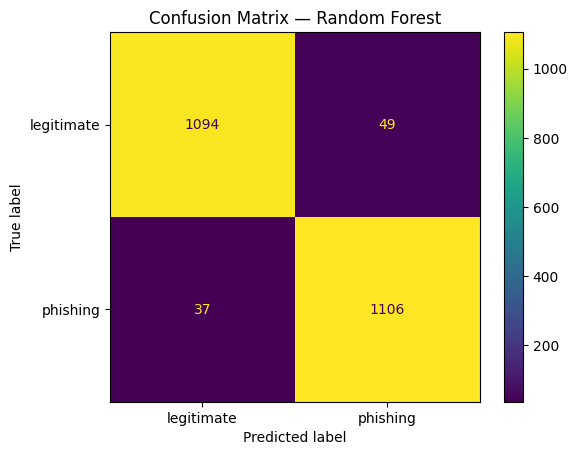

In [21]:
best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("Best model based on F1 score:", best_model_name)

best_predictions = best_model.predict(X_test)

print("\nClassification report:")
print(classification_report(
    y_test,
    best_predictions,
    target_names=["legitimate", "phishing"],
    digits=4
))

best_confusion_matrix = confusion_matrix(y_test, best_predictions)

ConfusionMatrixDisplay(
    best_confusion_matrix,
    display_labels=["legitimate", "phishing"]
).plot(values_format="d")

plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()

## 10.2 Soft Voting Ensemble

To follow the original project's ensemble idea, we create a soft voting classifier from the top three models.

In [22]:
top_three_model_names = results_df.head(3)["model"].tolist()
print("Top three models used in voting:", top_three_model_names)

voting_estimators = [
    (name.replace(" ", "_").lower(), trained_models[name])
    for name in top_three_model_names
]

soft_voting_model = VotingClassifier(
    estimators=voting_estimators,
    voting="soft"
)

soft_voting_result = evaluate_model(
    "Soft Voting Ensemble",
    soft_voting_model,
    X_train,
    X_test,
    y_train,
    y_test
)

comparison_df = pd.concat(
    [results_df, pd.DataFrame([soft_voting_result])],
    ignore_index=True
).sort_values("f1", ascending=False)

display(comparison_df)

Top three models used in voting: ['Random Forest', 'Extra Trees', 'Gradient Boosting']


,model,accuracy,precision,recall,f1,f2,mcc,roc_auc,tn,fp,fn,tp
0,Random Forest,0.962380,0.957576,0.967629,0.962576,0.965602,0.924810,0.993394,1094,49,37,1106
1,Extra Trees,0.958880,0.958880,0.958880,0.958880,0.958880,0.917760,0.991466,1096,47,47,1096
6,Soft Voting Ensemble,0.955818,0.951473,0.960630,0.956030,0.958784,0.911678,0.992910,1087,56,45,1098
2,Gradient Boosting,0.950569,0.945502,0.956255,0.950848,0.954085,0.901196,0.990326,1080,63,50,1093
3,Decision Tree,0.938758,0.937228,0.940507,0.938865,0.939850,0.877521,0.951891,1071,72,68,1075
4,K-Nearest Neighbors,0.939633,0.953930,0.923885,0.938667,0.929741,0.879702,0.978844,1092,51,87,1056
5,Logistic Regression,0.936133,0.939207,0.932633,0.935909,0.933941,0.872287,0.981422,1074,69,77,1066


# 11. Threshold Trade-Off Analysis

The default classification threshold is usually 0.5.  
In phishing detection, we may prefer higher recall to reduce False Negatives, even if this increases False Positives.

In [23]:
final_best_model_name = comparison_df.iloc[0]["model"]

if final_best_model_name == "Soft Voting Ensemble":
    final_best_model = soft_voting_model
else:
    final_best_model = trained_models[final_best_model_name]

if hasattr(final_best_model, "predict_proba"):
    y_scores = final_best_model.predict_proba(X_test)[:, 1]

    threshold_rows = []
    for threshold in [0.30, 0.40, 0.50, 0.60, 0.70]:
        threshold_predictions = (y_scores >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, threshold_predictions).ravel()

        threshold_rows.append({
            "threshold": threshold,
            "precision": precision_score(y_test, threshold_predictions, zero_division=0),
            "recall": recall_score(y_test, threshold_predictions, zero_division=0),
            "f1": f1_score(y_test, threshold_predictions, zero_division=0),
            "f2": fbeta_score(y_test, threshold_predictions, beta=2, zero_division=0),
            "fp": fp,
            "fn": fn
        })

    threshold_df = pd.DataFrame(threshold_rows)
    display(threshold_df)
else:
    print("The final best model does not support predict_proba, so threshold analysis was skipped.")

,threshold,precision,recall,f1,f2,fp,fn
0,0.3,0.905145,0.985127,0.943444,0.968019,118,17
1,0.4,0.936348,0.978128,0.956782,0.969476,76,25
2,0.5,0.957576,0.967629,0.962576,0.965602,49,37
3,0.6,0.972172,0.947507,0.959681,0.952339,31,60
4,0.7,0.984891,0.912511,0.947321,0.926123,16,100


# 12. Error Analysis

We inspect examples of model failures:

- False Positive: legitimate URL classified as phishing.
- False Negative: phishing URL classified as legitimate.

Cybersecurity interpretation:

- False Positives may annoy users or block legitimate work.
- False Negatives are more dangerous because a phishing URL reaches the user.

In [24]:
final_predictions = final_best_model.predict(X_test)

error_analysis_df = X_test.copy()
error_analysis_df["true_label"] = y_test.values
error_analysis_df["predicted_label"] = final_predictions
error_analysis_df["url"] = Dataset.loc[X_test.index, "url"].values
error_analysis_df["status"] = Dataset.loc[X_test.index, "status"].values

false_positives = error_analysis_df[
    (error_analysis_df["true_label"] == 0) &
    (error_analysis_df["predicted_label"] == 1)
]

false_negatives = error_analysis_df[
    (error_analysis_df["true_label"] == 1) &
    (error_analysis_df["predicted_label"] == 0)
]

print("Final best model:", final_best_model_name)
print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))

print("\nFalse Positive examples:")
display(false_positives[["url", "status", "true_label", "predicted_label"]].head(10))

print("\nFalse Negative examples:")
display(false_negatives[["url", "status", "true_label", "predicted_label"]].head(10))

Final best model: Random Forest
False Positives: 49
False Negatives: 37

False Positive examples:


,url,status,true_label,predicted_label
7176,http://turismo.biella.it/on-line/Home.html,legitimate,0,1
10295,http://iwanarif.lecturer.pens.ac.id/2.%20netwo...,legitimate,0,1
3358,http://francois-marie-arouet-voltaire.wikispac...,legitimate,0,1
4788,https://www.youtube.com/channel/UCLSjw7g5U48jg...,legitimate,0,1
2505,https://authenticjobs.com/jobs/29269,legitimate,0,1
5569,http://www.tutorialscollection.com/javascript-...,legitimate,0,1
2297,http://atmac.org/dvorak-keyboard-layout-switching,legitimate,0,1
6344,http://www.endicia.com/EndiciaProfessionalHelp...,legitimate,0,1
2692,http://www.cubaverdad.net/internet_access.htm,legitimate,0,1
8706,http://www.tetraining.net/r/infofile/home.html,legitimate,0,1



False Negative examples:


,url,status,true_label,predicted_label
2083,https://yolikers.com/token_gen.php,phishing,1,0
5279,https://fndtmc.com/,phishing,1,0
1914,https://www.namikeystonepa.org/xanax/,phishing,1,0
11205,https://www.todosprodutos.com.br,phishing,1,0
3835,http://www.essaudio.cc/,phishing,1,0
9592,https://www.kidskitchen.ru,phishing,1,0
1714,https://www.lmzrb.com,phishing,1,0
2274,http://tny.im/a6p~,phishing,1,0
9204,http://banrisul.com.br/bob/link/bobw00hn_conte...,phishing,1,0
7578,http://cashat.pro/,phishing,1,0


## 12.1 Error Pattern Inspection

We compare average feature values for false negatives and false positives.  
This helps identify whether model failures are related to specific URL/webpage patterns.

In [25]:
error_feature_subset = [
    feature for feature in [
        "length_url", "length_hostname", "nb_dots", "nb_hyphens",
        "ratio_digits_url", "phish_hints", "nb_hyperlinks",
        "web_traffic", "google_index", "page_rank", "domain_age"
    ]
    if feature in error_analysis_df.columns
]

if len(false_negatives) > 0:
    print("False Negative feature summary:")
    display(false_negatives[error_feature_subset].describe().T)

if len(false_positives) > 0:
    print("False Positive feature summary:")
    display(false_positives[error_feature_subset].describe().T)

False Negative feature summary:


,count,mean,std,min,25%,50%,75%,max
length_url,37.0,37.054054,2.101580e+01,17.0,23.0,31.0,43.0,9.900000e+01
length_hostname,37.0,17.864865,7.398056e+00,6.0,13.0,16.0,22.0,3.700000e+01
nb_dots,37.0,2.000000,9.428090e-01,1.0,1.0,2.0,2.0,5.000000e+00
nb_hyphens,37.0,0.135135,3.465835e-01,0.0,0.0,0.0,0.0,1.000000e+00
ratio_digits_url,37.0,0.017975,5.126979e-02,0.0,0.0,0.0,0.0,2.727273e-01
phish_hints,37.0,0.135135,5.355248e-01,0.0,0.0,0.0,0.0,3.000000e+00
nb_hyperlinks,37.0,119.945946,1.674395e+02,4.0,19.0,40.0,169.0,6.110000e+02
web_traffic,37.0,728306.702703,1.478685e+06,0.0,0.0,12091.0,518954.0,6.428932e+06
google_index,37.0,0.081081,2.767247e-01,0.0,0.0,0.0,0.0,1.000000e+00
page_rank,37.0,2.486486,2.116360e+00,0.0,1.0,2.0,4.0,9.000000e+00


False Positive feature summary:


,count,mean,std,min,25%,50%,75%,max
length_url,49.0,5.914286e+01,2.910040e+01,21.0,44.0,52.000000,6.400000e+01,1.890000e+02
length_hostname,49.0,1.959184e+01,8.378838e+00,7.0,14.0,18.000000,2.400000e+01,5.200000e+01
nb_dots,49.0,2.408163e+00,1.116512e+00,1.0,2.0,2.000000,3.000000e+00,7.000000e+00
nb_hyphens,49.0,1.346939e+00,2.376544e+00,0.0,0.0,0.000000,2.000000e+00,1.100000e+01
ratio_digits_url,49.0,5.409559e-02,7.590234e-02,0.0,0.0,0.020408,7.812500e-02,3.076923e-01
phish_hints,49.0,2.244898e-01,5.109349e-01,0.0,0.0,0.000000,0.000000e+00,2.000000e+00
nb_hyperlinks,49.0,3.228571e+01,5.679055e+01,0.0,2.0,12.000000,2.900000e+01,3.230000e+02
web_traffic,49.0,1.373185e+06,2.610703e+06,0.0,0.0,2.000000,1.148678e+06,8.858690e+06
google_index,49.0,8.163265e-01,3.912304e-01,0.0,1.0,1.000000,1.000000e+00,1.000000e+00
page_rank,49.0,2.775510e+00,2.064232e+00,0.0,2.0,2.000000,4.000000e+00,1.000000e+01


# 13. Feature Importance

For tree-based models, feature importance can help explain which features influenced the classification.

,importance
google_index,0.196847
page_rank,0.102609
web_traffic,0.089370
nb_hyperlinks,0.087238
nb_www,0.042725
ratio_extHyperlinks,0.037557
domain_age,0.028057
ratio_intHyperlinks,0.027899
longest_word_path,0.026497
phish_hints,0.024911


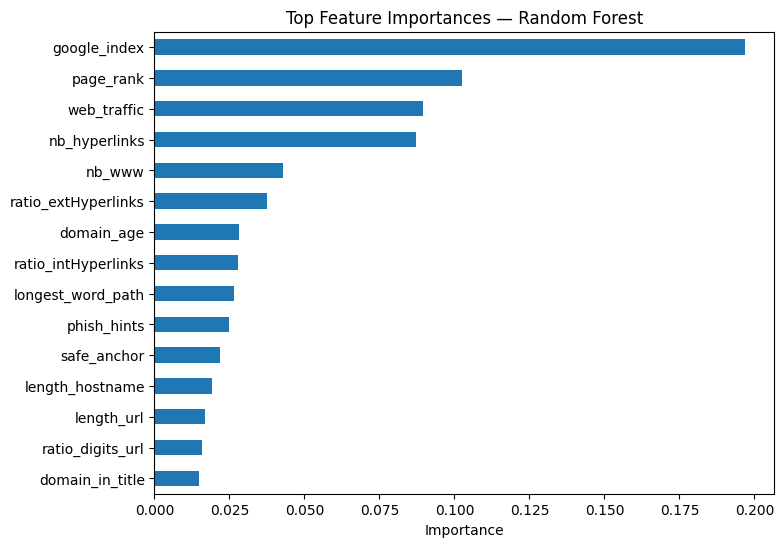

In [26]:
def get_feature_importance(model, feature_names):
    """Extract feature importance from tree-based models when available."""
    if hasattr(model, "feature_importances_"):
        return pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)

    if hasattr(model, "named_steps"):
        classifier = model.named_steps.get("classifier")
        if classifier is not None and hasattr(classifier, "feature_importances_"):
            return pd.Series(classifier.feature_importances_, index=feature_names).sort_values(ascending=False)

    return None


importance_series = get_feature_importance(final_best_model, X.columns)

if importance_series is not None:
    display(importance_series.head(20).rename("importance").to_frame())

    plt.figure(figsize=(8, 6))
    importance_series.head(15).sort_values().plot(kind="barh")
    plt.title(f"Top Feature Importances — {final_best_model_name}")
    plt.xlabel("Importance")
    plt.show()
else:
    print("Feature importance is not directly available for this model.")

# 14. Cross-Validation Check

A train/test split gives one estimate of performance.  
Cross-validation provides an additional robustness check across multiple folds.

In [27]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    final_best_model,
    X,
    y,
    cv=cv,
    scoring=cv_scoring,
    n_jobs=-1
)

cv_summary = pd.DataFrame({
    metric: [cv_results[f"test_{metric}"].mean(), cv_results[f"test_{metric}"].std()]
    for metric in cv_scoring
}, index=["mean", "std"]).T

display(cv_summary)

,mean,std
accuracy,0.963955,0.004406
precision,0.962705,0.006701
recall,0.965354,0.005410
f1,0.964009,0.004355
roc_auc,0.993162,0.001257


# 15. Save Results

In [28]:
results_dir = Path("results")
results_dir.mkdir(exist_ok=True)

comparison_df.to_csv(results_dir / "model_metrics.csv", index=False)

if "threshold_df" in globals():
    threshold_df.to_csv(results_dir / "threshold_analysis.csv", index=False)

cv_summary.to_csv(results_dir / "cross_validation_summary.csv")

print("Saved:")
print("- results/model_metrics.csv")
print("- results/threshold_analysis.csv")
print("- results/cross_validation_summary.csv")

Saved:
- results/model_metrics.csv
- results/threshold_analysis.csv
- results/cross_validation_summary.csv


# 16. Final Notebook Conclusions

This notebook adapted the selected GitHub phishing detection project to the approved `dataset_phishing.csv` file.

Main points:

1. The dataset contains URL and webpage-based engineered features.
2. The target variable was encoded from `status` to numeric `label`.
3. The dataset was inspected for missing values, duplicated rows, single-value features, and duplicated features.
4. No explicit temporal columns were found, so temporal drift could not be analyzed directly.
5. EDA included class balance, feature distributions, group-by/crosstab analysis, outlier analysis, and Spearman correlation.
6. Multiple machine learning models were trained and compared.
7. Evaluation used cybersecurity-relevant metrics, including precision, recall, F1, F2, MCC, ROC-AUC, and confusion matrix.
8. Error analysis focused on False Positives and False Negatives, with special attention to the risk of False Negatives in phishing detection.

The final report should use the results from this notebook to discuss whether the original project's approach is methodologically sound and whether its claims are supported by reproducible evidence.